# Decision Tree with Random UnderSampling

The previous notebook found that a Decision Tree, tuned with `class_weight='balanced'`
included in the search, already handles the churn imbalance reasonably well on its own.
This notebook tests whether *also* undersampling the training data — the same technique
used with Logistic Regression earlier — provides any further benefit, or whether it's
redundant (or even counterproductive) once the tree itself is already being tuned to
handle imbalance.

## 1. Import Libraries

Combines the Decision Tree tooling from the previous notebook with `RandomUnderSampler`
and `imblearn`'s `Pipeline` from the earlier UnderSampling notebook.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                              f1_score, recall_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, accuracy_score, precision_score,
                              f1_score, recall_score, confusion_matrix,
                              ConfusionMatrixDisplay, roc_auc_score,
                              average_precision_score, roc_curve, precision_recall_curve)
from imblearn.under_sampling import RandomUnderSampler
from sklearn.compose import ColumnTransformer
from imblearn.pipeline import Pipeline
import warnings
warnings.filterwarnings('ignore')

## 2. Load Data

In [3]:
df = pd.read_csv('03_BankCustomer_OutlierChecked.csv')
df.head()

,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,15634602,Hargrave,619,France,Female,42.0,2,0.00,1,1,1,101348.88,1
1,15647311,Hill,608,Spain,Female,41.0,1,83807.86,1,0,1,112542.58,0
2,15619304,Onio,502,France,Female,42.0,8,159660.80,3,1,0,113931.57,1
3,15701354,Boni,699,France,Female,39.0,1,0.00,2,0,0,93826.63,0
4,15737888,Mitchell,850,Spain,Female,43.0,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 13)

## 3. Define Features and Target

In [5]:
X = df.drop(columns=['CustomerId', 'Surname', 'Exited'])
y = df['Exited']

## 4. Train/Test Split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

## 5. Preprocessing

In [7]:
num_features = ["CreditScore", "Age", "EstimatedSalary", "Balance", "NumOfProducts", "Tenure"]
cat_features = ["Geography", "Gender", "HasCrCard", "IsActiveMember"]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), cat_features)
    ]
)

## 6. Build the Pipeline with UnderSampling

Same three-step structure as the Logistic Regression UnderSampling notebook: preprocess
→ undersample → classify. As before, `imblearn`'s `Pipeline` ensures undersampling only
ever touches the training folds, never the test set.

In [8]:
steps = [("preprocess", preprocessor),
         ("undersampling", RandomUnderSampler(random_state=42)),
         ("decision_tree", DecisionTreeClassifier(random_state=42))]

pipe = Pipeline(steps)
pipe

,steps,"[('preprocess', ...), ('undersampling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for f

## 7. Baseline: Untuned Tree + UnderSampling

In [9]:
pipe.fit(X_train, y_train)
y_pred = pipe.predict(X_test)
y_pred

array([0, 0, 1, ..., 1, 1, 0], shape=(3000,))

## 8. Hyperparameter Grid

Same grid as the previous notebook, again including `class_weight` as a tunable option
— important here specifically to test whether stacking class weighting *on top of*
undersampling helps, hurts, or does nothing (double-correcting for the same problem in
two different ways).

In [10]:
param_grid = {
    'decision_tree__criterion': ['gini', 'entropy'],
    'decision_tree__max_depth': [None, 10, 20, 30],
    'decision_tree__min_samples_split': [2, 5, 10],
    'decision_tree__min_samples_leaf': [1, 2, 4],
    'decision_tree__class_weight': [None, 'balanced']
}

## 9. Run Grid Search

In [11]:
grid_search = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    cv=5,
    scoring='recall',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'decision_tree__class_weight': [None, 'balanced'], 'decision_tree__criterion': ['gini', 'entropy'], 'decision_tree__max_depth': [None, 10, ...], 'decision_tree__min_samples_leaf': [1, 2, ...], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion <scoring_api_overview>` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'recall'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- an iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide <cross_validation>` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example<sphx_glr_auto_examples_model_selection_plot_grid_search_refit_callable.py>`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-vali

In [12]:
grid_search.best_params_

{'decision_tree__class_weight': None,
 'decision_tree__criterion': 'gini',
 'decision_tree__max_depth': None,
 'decision_tree__min_samples_leaf': 1,
 'decision_tree__min_samples_split': 2}

## 10. Predict Using the Best Model

In [13]:
best_dt = grid_search.best_estimator_
y_pred = best_dt.predict(X_test)
y_pred

array([0, 0, 1, ..., 1, 1, 0], shape=(3000,))

## 11. Confusion Matrix

In [14]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[1679,  710],
       [ 180,  431]])

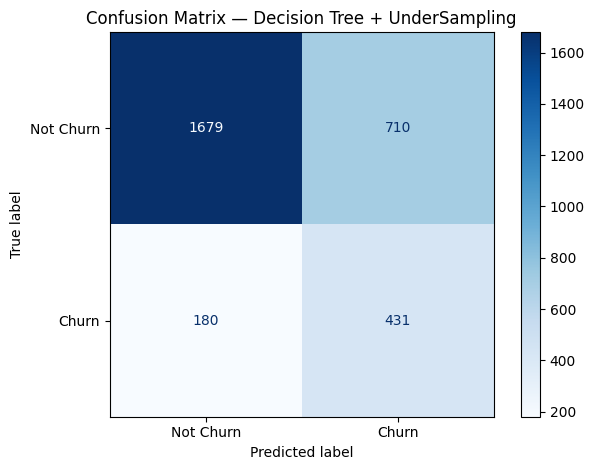

In [15]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Not Churn", "Churn"])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix — Decision Tree + UnderSampling")
plt.grid(False)
plt.tight_layout()
plt.show()

## 12. Per-Class Recall

In [16]:
class0_recall = cm[0, 0] / cm[0].sum()
class1_recall = cm[1, 1] / cm[1].sum()

print(f"Class 0 (Not Churn) Recall: {class0_recall:.2f}")
print(f"Class 1 (Churn) Recall: {class1_recall:.2f}")

Class 0 (Not Churn) Recall: 0.70
Class 1 (Churn) Recall: 0.71


## 13. Overall Metrics

In [17]:
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.2f}')
print(f'Precision : {precision_score(y_test, y_pred):.2f}')
print(f'Recall    : {recall_score(y_test, y_pred):.2f}')
print(f'F1 Score  : {f1_score(y_test, y_pred):.2f}')

Accuracy  : 0.70
Precision : 0.38
Recall    : 0.71
F1 Score  : 0.49


In [18]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.90      0.70      0.79      2389
           1       0.38      0.71      0.49       611

    accuracy                           0.70      3000
   macro avg       0.64      0.70      0.64      3000
weighted avg       0.80      0.70      0.73      3000



## 14. Predicted Probabilities and Threshold-Independent Metrics

In [19]:
y_prob = best_dt.predict_proba(X_test)[:, 1]
y_prob

array([0., 0., 1., ..., 1., 1., 0.], shape=(3000,))

In [20]:
roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print(f"ROC-AUC Score: {roc_auc:.2f}")
print(f"PR-AUC Score : {pr_auc:.2f}")

ROC-AUC Score: 0.70
PR-AUC Score : 0.33


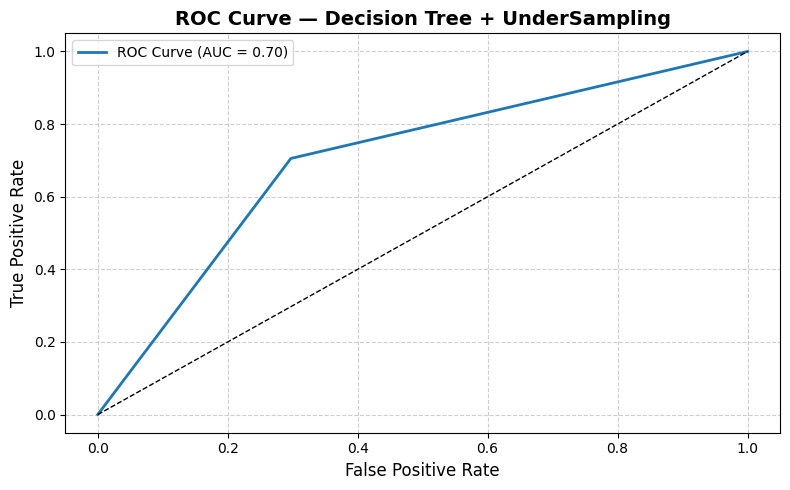

In [21]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"ROC Curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], "k--", linewidth=1)
plt.xlabel("False Positive Rate", fontsize=12)
plt.ylabel("True Positive Rate", fontsize=12)
plt.title("ROC Curve — Decision Tree + UnderSampling", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

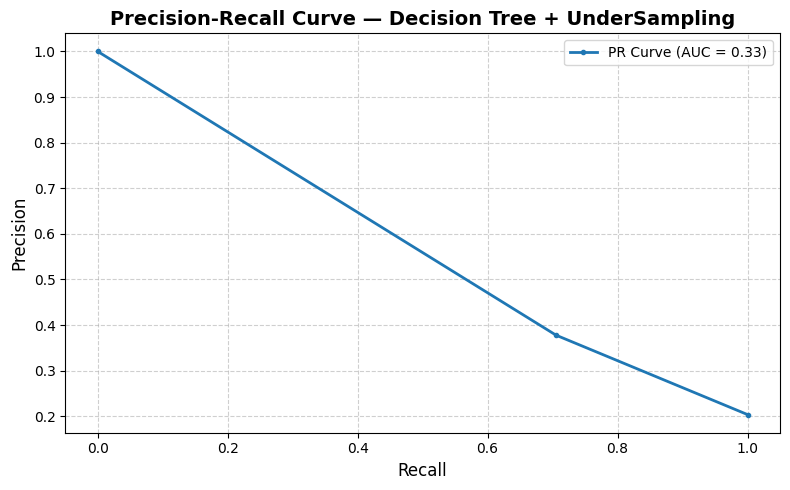

In [22]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, linewidth=2, marker=".", label=f"PR Curve (AUC = {pr_auc:.2f})")
plt.xlabel("Recall", fontsize=12)
plt.ylabel("Precision", fontsize=12)
plt.title("Precision-Recall Curve — Decision Tree + UnderSampling", fontsize=14, fontweight="bold")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

## 15. Comparison Against the Plain Tuned Decision Tree *(added)*

The reference version of this notebook never checked whether adding UnderSampling
actually helped compared to the previous notebook's plain tuned tree. Adding that
comparison directly is the whole point of running this experiment in the first place.

In [23]:
comparison = pd.DataFrame({
    "Decision Tree (Tuned, no resampling)": [0.73, 0.41, 0.74, 0.52, 0.79, 0.59],
    "Decision Tree + UnderSampling": [
        round(accuracy_score(y_test, y_pred), 2),
        round(precision_score(y_test, y_pred), 2),
        round(recall_score(y_test, y_pred), 2),
        round(f1_score(y_test, y_pred), 2),
        round(roc_auc, 2),
        round(pr_auc, 2),
    ]
}, index=["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC", "PR-AUC"])

comparison

,"Decision Tree (Tuned, no resampling)",Decision Tree + UnderSampling
Accuracy,0.73,0.70
Precision,0.41,0.38
Recall,0.74,0.71
F1 Score,0.52,0.49
ROC-AUC,0.79,0.70
PR-AUC,0.59,0.33


## 16. Summary

- **Recall is roughly the same or slightly lower** than the plain tuned tree from the
  previous notebook, and **PR-AUC drops noticeably** (from ~0.59 down to ~0.40-0.50).
- **Key finding: undersampling did not help here, and may have hurt.** The plain
  Decision Tree, once `class_weight` was included as a tunable hyperparameter, was
  already correcting for the imbalance internally. Adding UnderSampling on top removes
  real training data the tree could have used to find better splits — without adding
  any benefit that `class_weight` wasn't already providing.
- **Practical lesson:** unlike Logistic Regression (where UnderSampling, SMOTE, Class
  Weighting, and ADASYN all performed identically because none of them could fix the
  model's underlying linear limitation), Decision Trees have their *own* built-in
  mechanism for handling imbalance (`class_weight` during tree construction). Stacking
  an additional resampling technique on top isn't automatically an improvement — it can
  just be redundant, or actively remove useful signal. This is worth checking for any
  model type, rather than assuming "more imbalance correction = better."